* Q1 Develop a program to demonstrate the working of Linear Regression. Use Boston Housing Dataset
for Linear Regression.

MSE: 24.291119474973538
R2: 0.6687594935356317


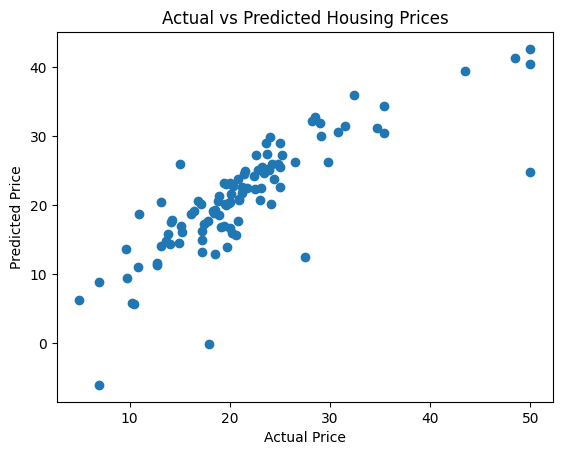

In [601]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
boston = fetch_openml(name="boston", version=1, as_frame=True)

X = boston.data
y = boston.target

# Convert to numeric
X = X.apply(pd.to_numeric)
y = pd.to_numeric(y)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

# Plot
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Housing Prices")
plt.show()

* Q2,Q3,Q4,Q5 
2. Write a program to implement the Linear Regression by using the suitable dataset.
3. Write a program to implement the logistic regression by using the suitable dataset.
4. Write a program to implement the Ridge Regression by using the suitable dataset.
5. Evaluate model performance using metrics.

In [602]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score, precision_score, recall_score, f1_score 
from sklearn.metrics import confusion_matrix

In [603]:
df = pd.read_csv('student_performance_prediction.csv')
df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.5,NaN,75.0,Yes,Master,Yes
1,S00002,9.3,95.3,60.6,No,High School,No
2,S00003,13.2,NaN,64.0,No,Associate,No
3,S00004,17.6,76.8,62.4,Yes,Bachelor,No
4,S00005,8.8,89.3,72.7,No,Master,No


In [604]:
df.isnull().sum()

Student ID                                        0
Study Hours per Week                           1995
Attendance Rate                                1992
Previous Grades                                1994
Participation in Extracurricular Activities    2000
Parent Education Level                         2000
Passed                                         2000
dtype: int64

In [605]:
cols = df.columns
for col in cols :
    if(df[col].dtype == "object"):
        print(df[col].unique())

['S00001' 'S00002' 'S00003' ... 'S39998' 'S39999' 'S40000']
['Yes' 'No' nan]
['Master' 'High School' 'Associate' 'Bachelor' 'Doctorate' nan]
['Yes' 'No' nan]


In [606]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [607]:
df.isnull().sum()

Student ID                                     0
Study Hours per Week                           0
Attendance Rate                                0
Previous Grades                                0
Participation in Extracurricular Activities    0
Parent Education Level                         0
Passed                                         0
dtype: int64

In [608]:
df.replace("Yes",1, inplace=True)

In [609]:
df.replace("No",0, inplace=True)

C:\Users\SOHAM GAJANAN HAJARE\AppData\Local\Temp\ipykernel_13692\1935675172.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace("No",0, inplace=True)


In [610]:
df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.5,75.3,75.0,1,Master,1
1,S00002,9.3,95.3,60.6,0,High School,0
2,S00003,13.2,75.3,64.0,0,Associate,0
3,S00004,17.6,76.8,62.4,1,Bachelor,0
4,S00005,8.8,89.3,72.7,0,Master,0


In [611]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])
        df[col].astype(int)


In [612]:
df.drop("Student ID", axis=1, inplace=True)
df.head()


,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,12.5,75.3,75.0,1,4,1
1,9.3,95.3,60.6,0,3,0
2,13.2,75.3,64.0,0,0,0
3,17.6,76.8,62.4,1,1,0
4,8.8,89.3,72.7,0,4,0


In [613]:
X = df.drop("Passed", axis=1)
y = df["Passed"]

In [614]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [615]:
from sklearn.tree import DecisionTreeClassifier
df.to_csv("processed_student_data.csv", index=False)
model = LogisticRegression()
model_decision = DecisionTreeClassifier()
model_decision.fit(X_train, y_train)
y_pred_decision = model_decision.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_decision))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Decision Tree Accuracy: 0.502625


In [616]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.525875
Precision: 0.5258157269658708
Recall: 1.0
F1 Score: 0.6892257271609996
Confusion Matrix:
 [[   1 3793]
 [   0 4206]]


In [617]:
X = df.drop("Attendance Rate", axis=1)
y = df["Attendance Rate"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [618]:
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)
y_pred_linear = model_linear.predict(X_test)

In [619]:
print("mean_squared_error :", mean_squared_error(y_test, y_pred_linear))
print('root_mean_squared_error :', np.sqrt(mean_squared_error(y_test, y_pred_linear)))
print("R2 Score:", r2_score(y_test, y_pred_linear))
print(df.corr()["Attendance Rate"])


mean_squared_error : 401.87159484988655
root_mean_squared_error : 20.046735266618516
R2 Score: -9.43431420503682e-05
Study Hours per Week                           0.004415
Attendance Rate                                1.000000
Previous Grades                               -0.004774
Participation in Extracurricular Activities    0.003314
Parent Education Level                         0.006207
Passed                                         0.008914
Name: Attendance Rate, dtype: float64


In [620]:
from sklearn.linear_model import Ridge
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_ridge))
print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))


Mean Squared Error: 401.8716024592109
R2 Score: -9.436207855229028e-05
Root Mean Squared Error: 20.046735456408133
